In [467]:
%load_ext autoreload
%autoreload 2

from koala.voronization import generate_lattice
from koala.pointsets import uniform, bluenoise
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm
from alter_morph.lattice_utilities import add_contacts
from scipy import linalg as la

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

from copy import copy
import numpy as np
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Lattice(440 vertices, 838 edges) Lattice(426 vertices, 622 edges) Lattice(430 vertices, 828 edges)


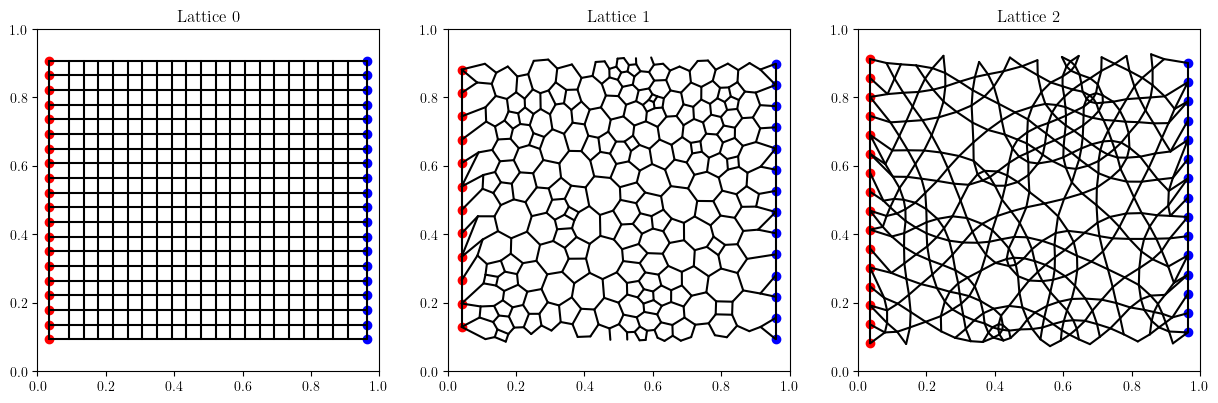

In [468]:
# generate the lattices
n_vertices = 20**2
points = uniform(n_vertices)

# generate lattice 0
rows = np.round(np.sqrt(n_vertices)).astype(int)
lattice0 = eg.square_lattice(rows, rows)
lattice0, boundaries0 = add_contacts(
    lattice0, cross_edges=True, return_added_indices=True, make_uniform=True
)

# generate lattice 1
vor_lat = generate_lattice(uniform(n_vertices // 2))
dimerisation = gu.dimerise(vor_lat)
lattice1 = gu.lloyd_relaxation(vor_lat, 10)
lattice1, boundaries1 = add_contacts(
    lattice1, cross_edges=True, return_added_indices=True, make_uniform=True
)
# lattice1 = gu.remove_trailing_edges(lattice1)

# generate lattice 2
l2 = generate_lattice(uniform(n_vertices // 3))
l2 = gu.lloyd_relaxation(l2, 10)
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
lattice2 = gu.dimer_collapse(exp_lat, dimer_exp)
lattice2, boundaries2 = add_contacts(
    lattice2, cross_edges=True, return_added_indices=True, make_uniform=True
)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for n, lat_bound in enumerate(
    [(lattice0, boundaries0), (lattice1, boundaries1), (lattice2, boundaries2)]
):
    lat, bound = lat_bound
    left_bound, right_bound = bound
    pl.plot_edges(lat, ax=ax[n])
    ax[n].set_aspect("equal")
    ax[n].set_title(f"Lattice {n}")
    ax[n].scatter(
        lat.vertices.positions[left_bound, 0],
        lat.vertices.positions[left_bound, 1],
        c="r",
    )
    ax[n].scatter(
        lat.vertices.positions[right_bound, 0],
        lat.vertices.positions[right_bound, 1],
        c="b",
    )

print(lattice0, lattice1, lattice2)

In [469]:
t1 = 1
t2 = 0.1
J = 0.5
filling = 0.5

lat = lattice1
boundaries = boundaries1
initial_m = np.zeros(lat.n_vertices) + 1.2

ham = alt_hamiltonian(lat, t1, t2, J, initial_m)
e, v = np.linalg.eigh(ham)

In [470]:
# setup initial conditions for the simulation
n_iterations = 10

fermi_occupation = np.linspace(0, 1, len(e)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = e[n_filled_states - 1]

initial_derived_m = find_m_values(v, filling)
initial_average_m_per_state = find_m_per_state(v)

# now let's do the mean field iteration
m_values = np.zeros((n_iterations + 1, lat.n_vertices))
m_values[0] = initial_m

prange = tqdm(range(n_iterations))
counter = 0
for n in prange:
    ham = alt_hamiltonian(lat, t1, t2, J, m_values[n])
    e, v = la.eigh(ham)
    m_values[n + 1] = find_m_values(v, filling)

    diff = np.linalg.norm(m_values[n + 1] - m_values[n])
    avg_m = np.mean(m_values[n + 1])
    prange.set_description(f"Avg:{avg_m:.2f}, diff: {diff:.6f}")

    if diff < 1e-6:
        counter += 1
        if counter > 2:
            m_values = m_values[: n + 1]
            break

Avg:1.96, diff: 0.000000:  90%|█████████ | 9/10 [00:11<00:01,  1.27s/it] 


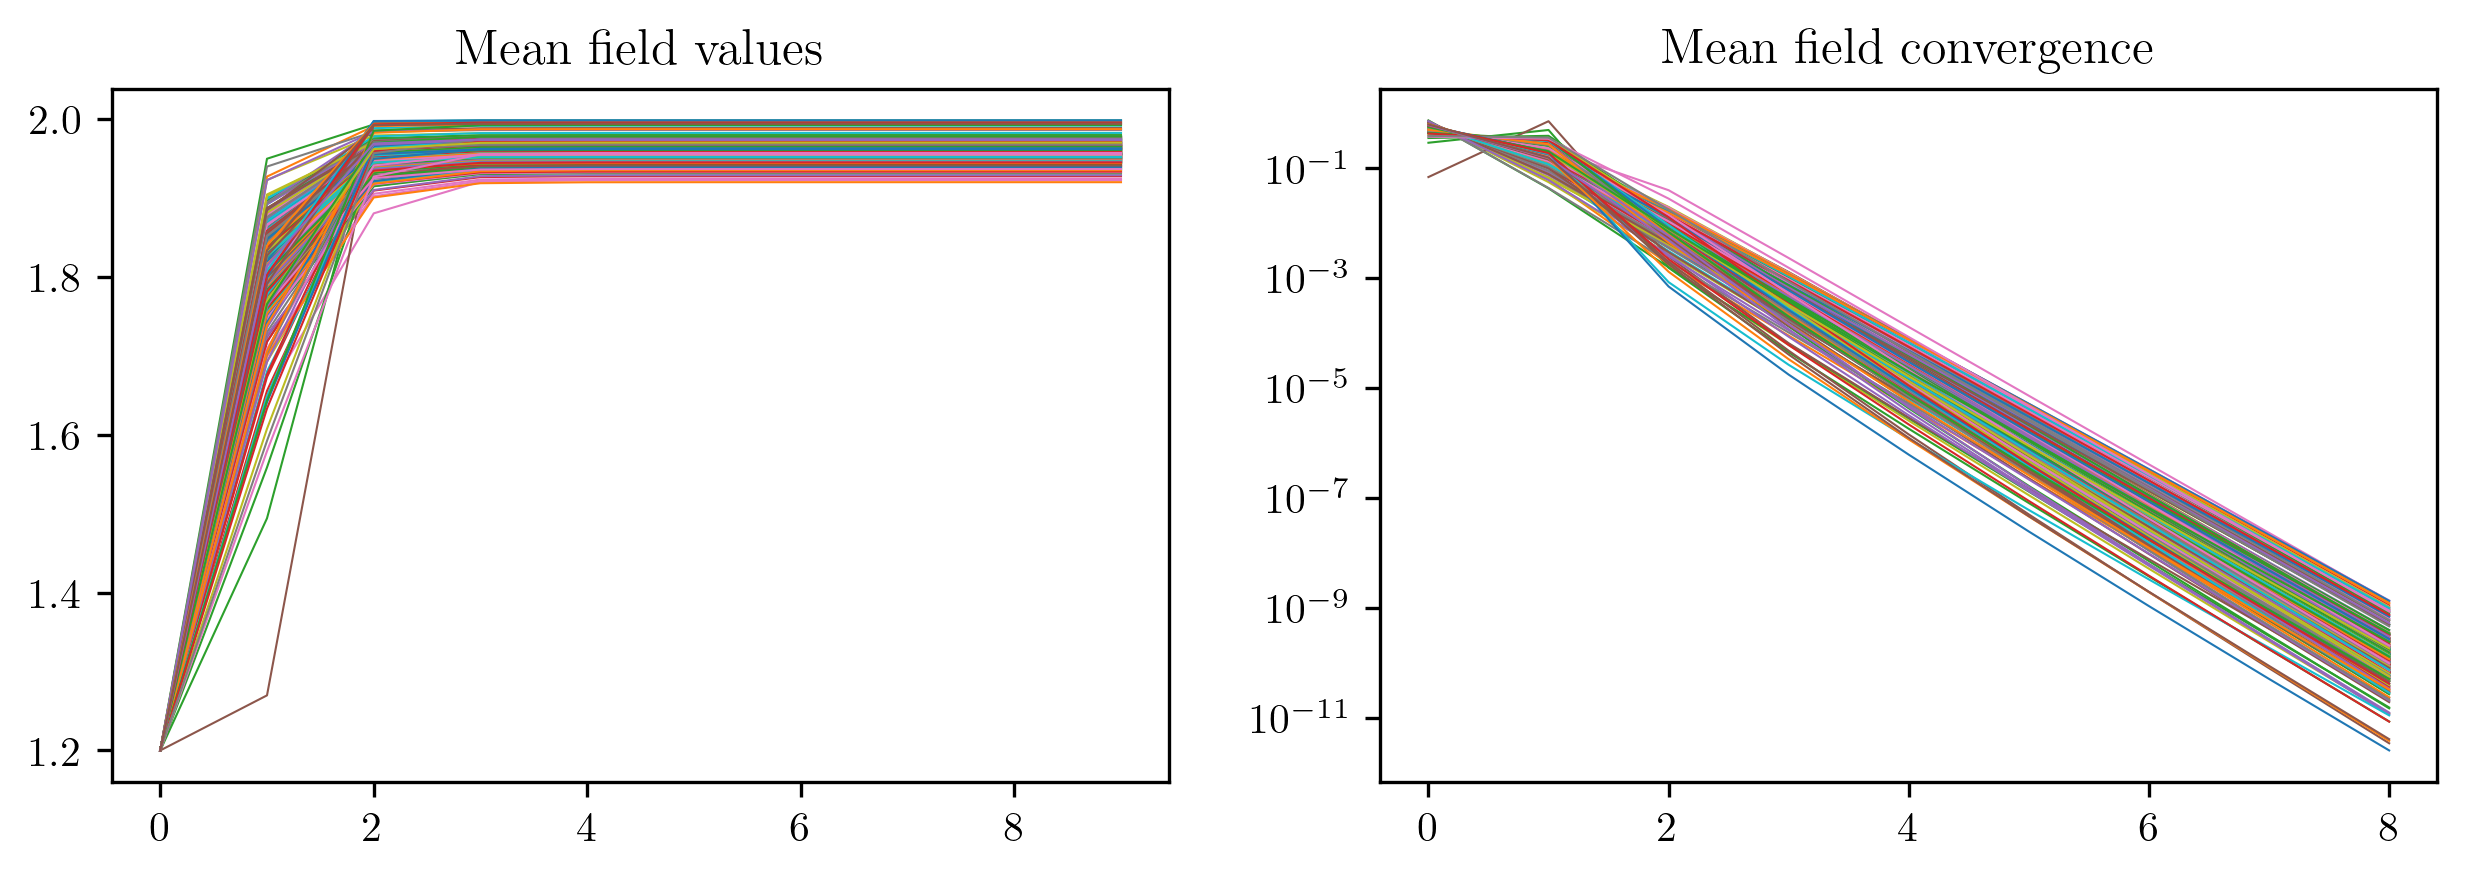

In [471]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3), dpi=300)
ax[0].plot(m_values, linewidth=0.5)

diffs = np.diff(m_values, axis=0)
ax[1].plot(np.abs(diffs), linewidth=0.5)


ax[0].set_title("Mean field values")
ax[1].set_title("Mean field convergence")
ax[1].set_yscale("log")
plt.show()

In [472]:
fermi_occupation = np.linspace(0, 1, len(e)) <= filling
n_filled_states = np.sum(fermi_occupation)
fermi_energy = e[n_filled_states - 1]

real_space_occupation = fermi_occupation[None, :] * (v * v.conj())
average_occupation = np.sum(real_space_occupation, axis=1)
average_occupation = (
    average_occupation[::4]
    + average_occupation[1::4]
    + average_occupation[2::4]
    + average_occupation[3::4]
)

ipr = np.sum(v**4, axis=0)

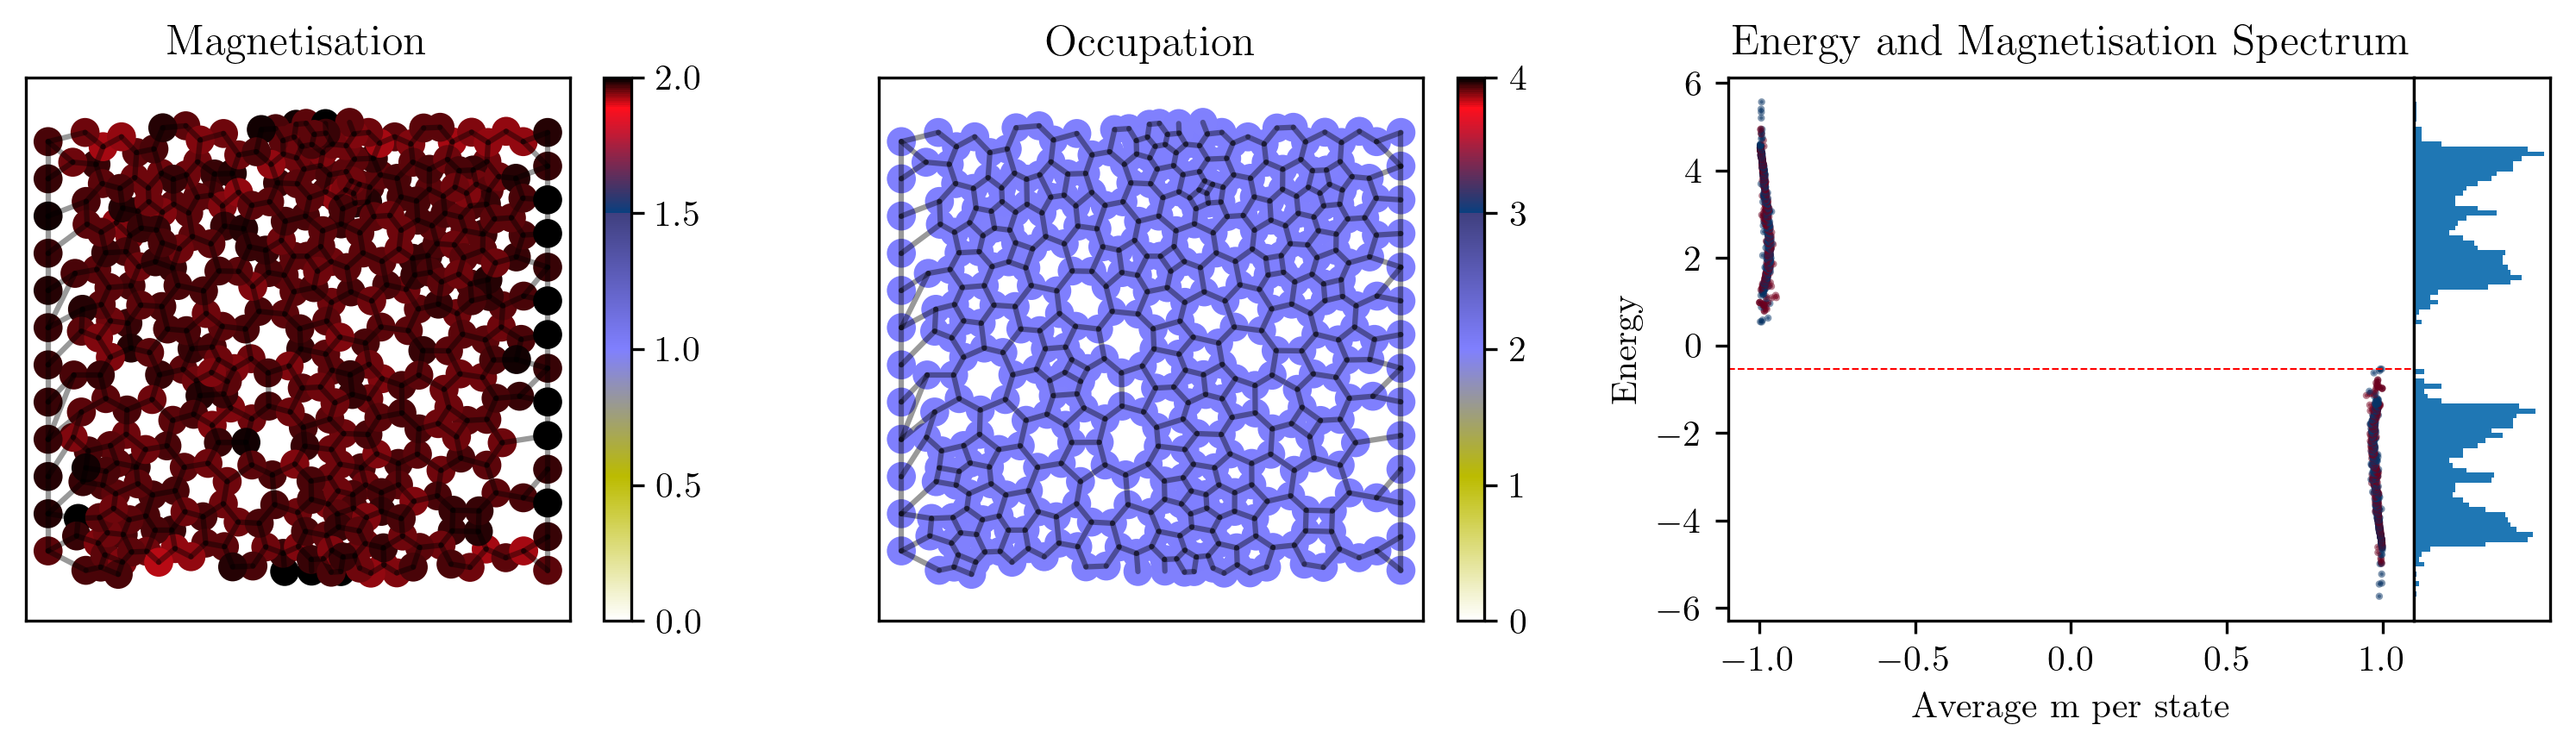

In [473]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)


average_m_per_state = find_m_per_state(v)
average_spin_per_state = find_spin_per_state(v)

m_values_out = m_values[-1]

vertices = lat.vertices.positions
pl.plot_edges(lat, ax=ax[0], alpha=0.4)
im = ax[0].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=m_values_out,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax[0])
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Magnetisation")


pl.plot_edges(lat, ax=ax[1], alpha=0.4)
im = ax[1].scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=average_occupation,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=4,
)
plt.colorbar(im, ax=ax[1])
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Occupation")

im = ax[2].scatter(
    average_m_per_state, e, s=1, c=average_spin_per_state, cmap="RdBu", alpha=0.5
)
ax[2].set_xlabel("Average m per state")
ax[2].set_ylabel("Energy")


ax_histy = ax[2].inset_axes([1.0, 0, 0.2, 1])
ax[2].axhline(fermi_energy, color="r", linestyle="--", linewidth=0.5)
ax[2].set_title("Energy and Magnetisation Spectrum")
# move ticks to left
ax[2].yaxis.tick_left()
# plt.colorbar(im, ax=ax[2], label="IPR",

ax_histy.hist(e, bins=100, orientation="horizontal")
ax_histy.set_xticks([])
ax_histy.set_yticks([])

plt.tight_layout()

[0.04082483 0.12889151] [0.04082483 0.88159187]


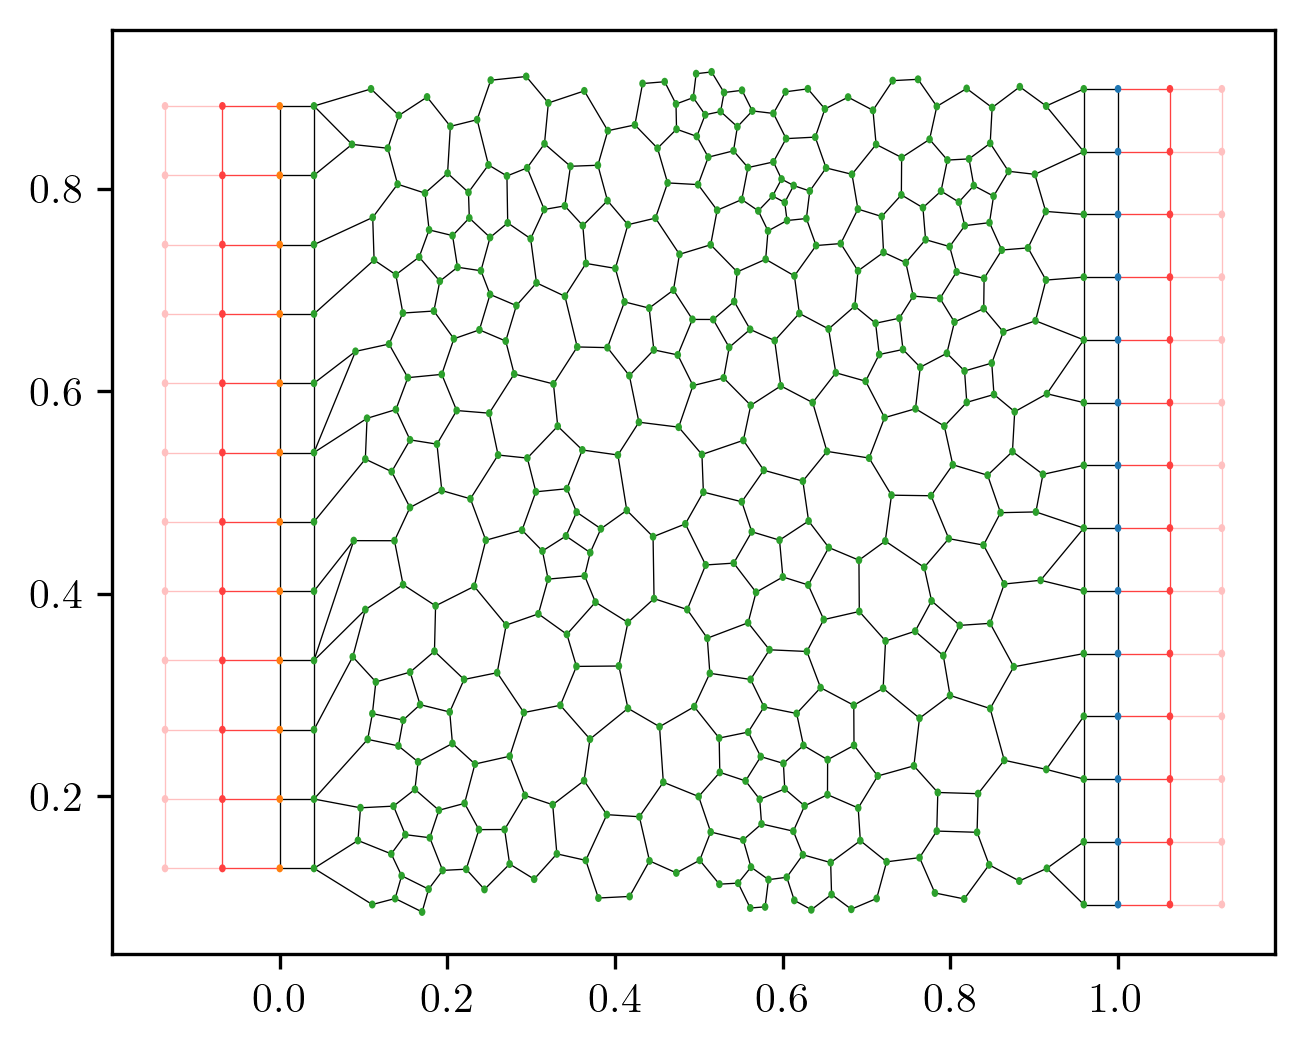

1.883626807109498

In [475]:
from alter_morph.hamiltonians import _hopping_matrix

# turn the system into a kwant system
import kwant
from alter_morph.kwant_utilities import kwant_altermagnetic_hamiltonian

k_system, k_lattice = kwant_altermagnetic_hamiltonian(
    lat, t1, t2, J, m_values[-1], return_lattice=True
)


horizontal_hopping = _hopping_matrix(t1, t2, 0)
vertical_hopping = _hopping_matrix(t1, t2, np.pi / 2)
# create leads and attach them


# find the average magnetisation, which we use for the leads onsite energies
average_magnetisation = np.mean(m_values[-1])

# find left and right boundaries
left_vertices = boundaries[0]
right_vertices = boundaries[1]
left_positions = lat.vertices.positions[left_vertices]
right_positions = lat.vertices.positions[right_vertices]

# lattice spacings for leads
left_y_range = (np.min(left_positions[:, 1]), np.max(left_positions[:, 1]))
right_y_range = (np.min(right_positions[:, 1]), np.max(right_positions[:, 1]))
left_a = (left_y_range[1] - left_y_range[0]) / (len(left_vertices) - 1)
right_a = (right_y_range[1] - right_y_range[0]) / (len(right_vertices) - 1)
left_shift = left_y_range[0] / left_a
right_shift = right_y_range[0] / right_a


# create leads
left_lead_lattice = kwant.lattice.square(a=left_a, norbs=4)
left_lead_lattice.offset = (0, left_y_range[0])
left_lead_symmetry = kwant.TranslationalSymmetry(left_lead_lattice.vec((-1, 0)))
left_lead = kwant.Builder(left_lead_symmetry)

right_lead_lattice = kwant.lattice.square(a=right_a, norbs=4)
right_lead_lattice.offset = (1, right_y_range[0])
right_lead_symmetry = kwant.TranslationalSymmetry(right_lead_lattice.vec((1, 0)))
right_lead = kwant.Builder(right_lead_symmetry)

# add the couplings and onsite energies to the leads

# onsite energies
left_number_of_neighbours = np.full(len(left_vertices), 4, dtype=int)
left_number_of_neighbours[[0, -1]] = 3
left_onsites = [
    J * average_magnetisation * neighbour * np.diag(np.array([-1, 1, 1, -1]))
    for neighbour in left_number_of_neighbours
]
right_number_of_neighbours = np.full(len(right_vertices), 4, dtype=int)
right_number_of_neighbours[[0, -1]] = 3
right_onsites = [
    J * average_magnetisation * neighbour * np.diag(np.array([-1, 1, 1, -1]))
    for neighbour in right_number_of_neighbours
]

for i, on in enumerate(left_onsites):
    left_lead[left_lead_lattice(0, i)] = on
for i, on in enumerate(right_onsites):
    right_lead[right_lead_lattice(0, i)] = on

# couplings -for now we just use the averaged hopping with no directionality
left_lead[left_lead_lattice.neighbors()] = (horizontal_hopping + vertical_hopping) / 2
right_lead[right_lead_lattice.neighbors()] = (horizontal_hopping + vertical_hopping) / 2


# add sites from leads to the system

for i, on in enumerate(left_onsites):
    k_system[(left_lead_lattice(0, i))] = on
    k_system[left_lead_lattice(0, i), k_lattice(left_vertices[i])] = (
        horizontal_hopping + vertical_hopping
    ) / 2
k_system[left_lead_lattice.neighbors()] = (horizontal_hopping + vertical_hopping) / 2

for i, on in enumerate(right_onsites):
    k_system[right_lead_lattice(0, i)] = on
    k_system[right_lead_lattice(0, i), k_lattice(right_vertices[i])] = (
        horizontal_hopping + vertical_hopping
    ) / 2
k_system[right_lead_lattice.neighbors()] = (horizontal_hopping + vertical_hopping) / 2

k_system.attach_lead(left_lead)
k_system.attach_lead(right_lead)
k_system.eradicate_dangling()

k_final = k_system.finalized()

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=300)
kwant.plot(k_system, ax=ax)
plt.show()

left_shift

TypeError: print() argument after * must be an iterable, not NoneType